In [63]:
import numpy as np
from matplotlib import pyplot as plt
from astroML.datasets import generate_mu_z
import emcee
from scipy.stats import norm
from scipy.integrate import trapezoid
import corner
from sklearn.neighbors import KernelDensity

(100, 3)


(35.0, 50.0)

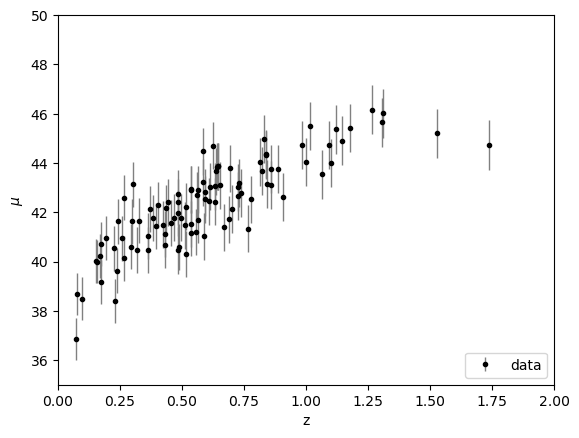

In [ ]:
#generating the sample
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

data = np.vstack((z_sample, mu_sample, dmu)).T

#preliminary data plot
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

We want to fit the data with a parametric model (given by cosmology): 

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z)^3+\Omega_\Lambda}} \right) $$

Assuming a flat universe $\Omega_m + \Omega_\Lambda = 1$, hence the model depends only on two parameters: $H_0, \Omega_\Lambda$ (or equivalently $\Omega_m$).

We set up an MCMC to sample the parameters' posterior, considering a gaussian Likelihood and uniform priors (on ranges informed by previous cosmological measures).

## Paramertic fit with MCMC

In [101]:
def Integral(z, omega_l, ds=1e-4): 
    integrand = lambda s: 1./np.sqrt((1 - omega_l)*np.pow((1+s), 3) + omega_l)
    
    n = int(z/ds)
    s_grid = np.linspace(0, z, n)
    y_grid = integrand(s_grid)
    
    I = trapezoid(y_grid, s_grid) # integrating with the trapezoid method
    return I

def model(x, z): # parametric model
    H0, omega_l = x
    arg = (float(3e10)/H0)*(1+z)*Integral(z, omega_l) # considering [H0] = Km/s/Mpc 
    if (arg <= 0.):
        return np.nan
    return 5*np.log10(arg)

def logLikelihood(x, data):
    logL = 0.
    for measure in data:
        mean_i = model(x, measure[0])
        sigma_i = measure[2]
        if not np.isfinite(mean_i):
            return -np.inf
        lik_i = norm(mean_i, sigma_i).pdf(measure[1]) # heteroscedastic gaussian likelihood
        if (lik_i <= 0) or not np.isfinite(lik_i):
            return -np.inf
        logL += np.log(lik_i)
    return logL


def logPrior(x): # uniform prior (but informed ranges)
    H0, omega_l = x
    if not (50. < H0 < 100. and 0. <= omega_l < 1.):
        return -np.inf
    return np.log(1./50.)

def logPosterior(x, data):
    return logLikelihood(x, data) + logPrior(x)


In [ ]:
ndim = 2 # number of parameters
nwalkers = 5 # number of walkers mapping the posterior
nsteps = 10000 # numbe of steps in the Markov chain

#initializing the random walkers
starting_guesses = []
for i in range(nwalkers):
    starting_guesses.append([70.+norm(0., 4.).rvs(),
                             np.random.random()])

# running the chain
MC_sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=[data])
MC_sampler.run_mcmc(starting_guesses, nsteps)

/tmp/ipykernel_36941/1081692121.py:3: RuntimeWarning: invalid value encountered in sqrt
  integrand = lambda s: 1./np.sqrt((1 - omega_l)*np.pow((1+s), 3) + omega_l)


State([[69.19011323  0.7629058 ]
 [65.36741355  0.50441185]
 [65.1862832   0.23949164]
 [66.40938724  0.46401459]
 [59.21935239  0.39667844]], log_prob=[-137.05670662 -136.79730432 -138.38209875 -137.056635   -138.07191543], blobs=None, random_state=('MT19937', array([1495550562, 1615080759, 1613133702, 1317175765, 1381641059,
       2472113175, 1412123010, 3823036648,  773508247, 1572414723,
        531441529, 3953592914, 2796501432, 3729138418, 4083993374,
       2945527113, 3929591385,  887070147, 3924636332, 3234655937,
       4146134941, 4125749816, 1958158807,  605163150, 2454763891,
       1974308202, 2708934981, 2450736748,  700431795, 1475701863,
        467192122, 2478122014, 3060607050, 2726792498, 2553918218,
       3609961999, 1905509601, 1484076262, 2022623319, 1595163330,
       3189824522, 1218362142, 1961958476, 3261068251,  878668054,
       4059526568, 2340408845, 1753892059, 2741291315,  461365467,
       1003682979, 3018197644, 3764410436, 3081011552, 3141742730,
 

Text(0.5, 0, '$n_{step}$')

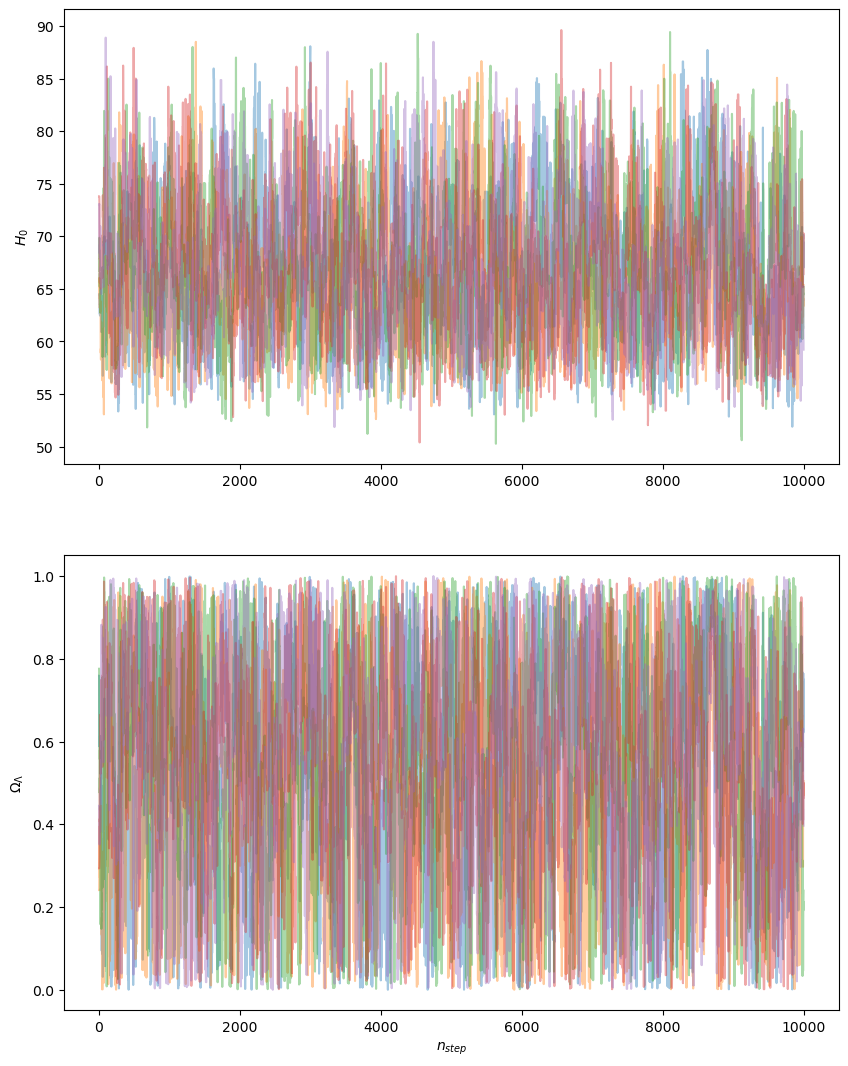

In [103]:
# checking the run with trace plots
param = ['$H_{0}$', '$\\Omega_{\\Lambda}$']   
fig, ax = plt.subplots(2, figsize=(10, 13))
for j in range(ndim):
    ax_j = ax[j]
    ax_j.set_ylabel(param[j])
    for i in range(nwalkers):
        ax_j.plot(MC_sampler.chain[i, :, j], alpha=0.4) #change the range in the chain to check the burn in period
ax[-1].set_xlabel('$n_{step}$')

In [89]:
print(MC_sampler.acceptance_fraction)

[0.6845 0.702  0.6805 0.6915 0.6848]


The walkers seem to be mixing well, to be conservative we discard the first 1000 steps as 'burn-in'. We then thin the chain by computing the autocorrelation time for each parameter and choosing the maximum

(920, 2)

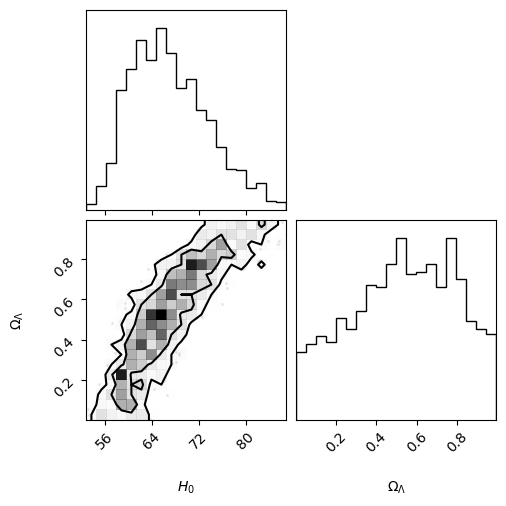

In [ ]:
chain = MC_sampler.get_chain()

burn = 1000 # burn-in steps
tau_vect = emcee.autocorr.integrated_time(chain) #autocorrelation time
thin = int(max(tau_vect)+1)

reshaped_chain = chain[burn::thin, :, :]
flat_chain = reshaped_chain.reshape(-1, reshaped_chain.shape[-1])

#plotting the joint and marginalized posteriors
c_plot = corner.corner(flat_chain, labels=param, levels=[0.68, 0.95])

The joint posterior highlights correlation between the parameters.

We now sample the posterior and plot a few of the corresponding models over the data:

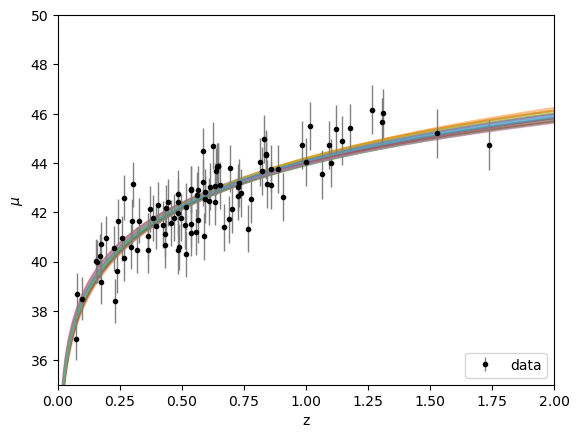

In [ ]:
idx = np.random.choice(np.arange(len(flat_chain)), 20) # random choices

z_grid = np.linspace(0., 2., 10000)
for i in idx:
    
    mu_vals = [model(flat_chain[i], z_i) for z_i in z_grid] # evaluating the models
    plt.plot(z_grid, mu_vals, alpha=0.5)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()


Considering the marginalized posteriors, let's compute the median value and the 90% CL interval for each parameter

In [91]:
results = [] #stores the medians and the limits of the credible region
median_params = []
labels= ['H0', 'Omega_Lambda']

for i in range(len(param)):
    chain_par = flat_chain[:, i]
    median = np.median(chain_par)
    low_limit, up_limit = np.quantile(chain_par, [0.05, 0.95])
    results.append([median, median-low_limit, up_limit-median])
    median_params.append(median)
    print(f"{labels[i]} = {median:.2f} [{low_limit:.2f}, {up_limit:.2f}] (90% CL)")

H0 = 66.36 [58.05, 79.41] (90% CL)
Omega_Lambda = 0.54 [0.08, 0.93] (90% CL)


## Model comparison (dark energy)

We want to determine whether the measurements can discriminate between models with and without dark energy. Being the latter a special case of the one already considered (with $\Omega_\Lambda = 0$), we can compute the Bayes factor using the Savage-Dickey density ratio.

In [ ]:
# using KDE to construct the marginalized posterior for Omega_Lambda
KDE = KernelDensity(bandwidth=0.2, kernel='epanechnikov')
KDE.fit(flat_chain[:, 1][:, None])

,bandwidth,0.2
,algorithm,'auto'
,kernel,'epanechnikov'
,metric,'euclidean'
,atol,0
,rtol,0
,breadth_first,True
,leaf_size,40
,metric_params,None


Text(0.5, 0, '$\\Omega_\\Lambda$')

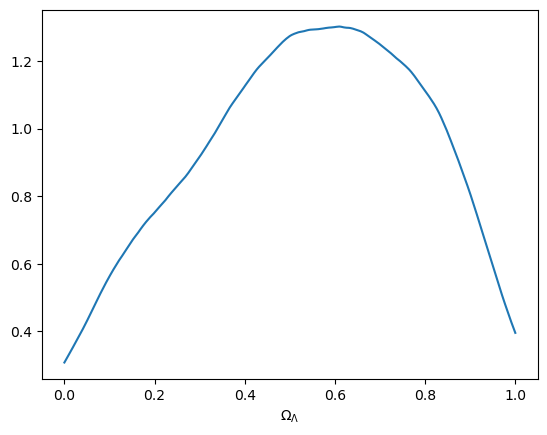

In [ ]:
#plotting the distribution
x_grid = np.linspace(0., 1., 10000)
y_grid = np.exp(KDE.score_samples(x_grid[:, None]))

plt.plot(x_grid, y_grid)
plt.xlabel('$\Omega_\Lambda$')

Being the marginalized prior at $\Omega_\Lambda = 0$ equal to 1. Then the Bayes factor $B$:

In [116]:
x = np.array([0.])
B = 1./np.exp(KDE.score(x[:, None]))

print(f'B = {B:.2f}')

B = 3.25


Which gives us somewhat of a weak evidence for dark energy, but not really conclusive